# Cognifyz Machine Learning Internship

## Task 2 — Restaurant Recommendation System

### Objective

Create a restaurant recommendation system based on user preferences.

### Approach

A content-based filtering approach will be used to recommend
restaurants that are similar to the user's preferred criteria.

### Recommendation Criteria

- Cuisine preference
- Price range
- City
- Restaurant rating
- Online delivery
- Table booking

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv(
    "../outputs/results/cleaned_restaurant_dataset.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (9551, 22)


In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Primary Cuisine
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,French
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Japanese
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Seafood
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Japanese
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Japanese


In [4]:
recommendation_columns = [
    "Restaurant Name",
    "City",
    "Locality",
    "Cuisines",
    "Price range",
    "Aggregate rating",
    "Has Online delivery",
    "Has Table booking"
]

df[recommendation_columns].head()

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking
0,Le Petit Souffle,Makati City,"Century City Mall, Poblacion, Makati City","French, Japanese, Desserts",3,4.8,No,Yes
1,Izakaya Kikufuji,Makati City,"Little Tokyo, Legaspi Village, Makati City",Japanese,3,4.5,No,Yes
2,Heat - Edsa Shangri-La,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City","Seafood, Asian, Filipino, Indian",4,4.4,No,Yes
3,Ooma,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City","Japanese, Sushi",4,4.9,No,No
4,Sambo Kojin,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City","Japanese, Korean",4,4.8,No,Yes


In [5]:
df[recommendation_columns].isnull().sum()

Restaurant Name        0
City                   0
Locality               0
Cuisines               0
Price range            0
Aggregate rating       0
Has Online delivery    0
Has Table booking      0
dtype: int64

In [6]:
rec_df = df[recommendation_columns].copy()

In [7]:
rec_df.head()

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking
0,Le Petit Souffle,Makati City,"Century City Mall, Poblacion, Makati City","French, Japanese, Desserts",3,4.8,No,Yes
1,Izakaya Kikufuji,Makati City,"Little Tokyo, Legaspi Village, Makati City",Japanese,3,4.5,No,Yes
2,Heat - Edsa Shangri-La,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City","Seafood, Asian, Filipino, Indian",4,4.4,No,Yes
3,Ooma,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City","Japanese, Sushi",4,4.9,No,No
4,Sambo Kojin,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City","Japanese, Korean",4,4.8,No,Yes


In [8]:
text_columns = [
    "City",
    "Locality",
    "Cuisines"
]

for col in text_columns:
    rec_df[col] = (
        rec_df[col]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

In [9]:
rec_df[
    ["City", "Locality", "Cuisines"]
].head()

,City,Locality,Cuisines
0,makati city,"century city mall, poblacion, makati city","french, japanese, desserts"
1,makati city,"little tokyo, legaspi village, makati city",japanese
2,mandaluyong city,"edsa shangri-la, ortigas, mandaluyong city","seafood, asian, filipino, indian"
3,mandaluyong city,"sm megamall, ortigas, mandaluyong city","japanese, sushi"
4,mandaluyong city,"sm megamall, ortigas, mandaluyong city","japanese, korean"


In [10]:
rec_df["Price range"].value_counts().sort_index()

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

In [11]:
rec_df["Aggregate rating"].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

In [12]:
rec_df["content"] = (
    rec_df["Cuisines"] + " " +
    rec_df["Locality"] + " " +
    rec_df["City"]
)

In [13]:
rec_df[
    [
        "Restaurant Name",
        "City",
        "Locality",
        "Cuisines",
        "content"
    ]
].head()

,Restaurant Name,City,Locality,Cuisines,content
0,Le Petit Souffle,makati city,"century city mall, poblacion, makati city","french, japanese, desserts","french, japanese, desserts century city mall, ..."
1,Izakaya Kikufuji,makati city,"little tokyo, legaspi village, makati city",japanese,"japanese little tokyo, legaspi village, makati..."
2,Heat - Edsa Shangri-La,mandaluyong city,"edsa shangri-la, ortigas, mandaluyong city","seafood, asian, filipino, indian","seafood, asian, filipino, indian edsa shangri-..."
3,Ooma,mandaluyong city,"sm megamall, ortigas, mandaluyong city","japanese, sushi","japanese, sushi sm megamall, ortigas, mandaluy..."
4,Sambo Kojin,mandaluyong city,"sm megamall, ortigas, mandaluyong city","japanese, korean","japanese, korean sm megamall, ortigas, mandalu..."


In [14]:
tfidf = TfidfVectorizer(
    stop_words="english"
)

In [15]:
tfidf_matrix = tfidf.fit_transform(
    rec_df["content"]
)

In [16]:
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9551, 1561)


In [17]:
cosine_sim = cosine_similarity(tfidf_matrix)

In [18]:
print("Similarity matrix shape:", cosine_sim.shape)

Similarity matrix shape: (9551, 9551)


In [19]:
cosine_similarity(tfidf_matrix)

array([[1.        , 0.62525117, 0.15797053, ..., 0.        , 0.        ,
        0.        ],
       [0.62525117, 1.        , 0.1090209 , ..., 0.        , 0.        ,
        0.        ],
       [0.15797053, 0.1090209 , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.6816648 ,
        0.23577763],
       [0.        , 0.        , 0.        , ..., 0.6816648 , 1.        ,
        0.31657817],
       [0.        , 0.        , 0.        , ..., 0.23577763, 0.31657817,
        1.        ]], shape=(9551, 9551))

In [20]:
indices = pd.Series(
    rec_df.index,
    index=rec_df["Restaurant Name"].str.lower()
).drop_duplicates()

In [21]:
indices.head()

Restaurant Name
le petit souffle          0
izakaya kikufuji          1
heat - edsa shangri-la    2
ooma                      3
sambo kojin               4
dtype: int64

In [22]:
def recommend_similar_restaurants(
    restaurant_name,
    top_n=10
):
    restaurant_name = restaurant_name.lower()

    if restaurant_name not in indices:
        return pd.DataFrame()

    idx = indices[restaurant_name]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n + 1]

    restaurant_indices = [
        i[0] for i in similarity_scores
    ]

    result = rec_df.iloc[
        restaurant_indices
    ].copy()

    result["Similarity Score"] = [
        i[1] for i in similarity_scores
    ]

    return result

In [23]:
rec_df[
    "Restaurant Name"
].head(10)

0                            Le Petit Souffle
1                            Izakaya Kikufuji
2                      Heat - Edsa Shangri-La
3                                        Ooma
4                                 Sambo Kojin
5                                Din Tai Fung
6                                  Buffet 101
7                                     Vikings
8    Spiral - Sofitel Philippine Plaza Manila
9                                    Locavore
Name: Restaurant Name, dtype: str

In [24]:
recommend_similar_restaurants(
    "Restaurant X",
    top_n=5
)

""


In [25]:
user_preferences = {
    "city": "New Delhi",
    "cuisine": "North Indian",
    "price_range": 2,
    "min_rating": 4.0,
    "online_delivery": "Yes"
}

user_preferences

{'city': 'New Delhi',
 'cuisine': 'North Indian',
 'price_range': 2,
 'min_rating': 4.0,
 'online_delivery': 'Yes'}

In [26]:
filtered_df = rec_df.copy()

In [27]:
filtered_df = filtered_df[
    filtered_df["City"] == user_preferences["city"].lower()
]

In [28]:
filtered_df = filtered_df[
    filtered_df["Price range"] ==
    user_preferences["price_range"]
]

In [29]:
filtered_df = filtered_df[
    filtered_df["Aggregate rating"] >=
    user_preferences["min_rating"]
]

In [30]:
filtered_df = filtered_df[
    filtered_df["Has Online delivery"] ==
    user_preferences["online_delivery"]
]

In [31]:
print("Restaurants matching filters:", len(filtered_df))

Restaurants matching filters: 59


In [32]:
user_content = (
    user_preferences["cuisine"].lower() + " " +
    user_preferences["city"].lower()
)

In [33]:
user_vector = tfidf.transform(
    [user_content]
)

In [34]:
rec_df["Restaurant Name"].head(10)

0                            Le Petit Souffle
1                            Izakaya Kikufuji
2                      Heat - Edsa Shangri-La
3                                        Ooma
4                                 Sambo Kojin
5                                Din Tai Fung
6                                  Buffet 101
7                                     Vikings
8    Spiral - Sofitel Philippine Plaza Manila
9                                    Locavore
Name: Restaurant Name, dtype: str

In [35]:
recommend_similar_restaurants(
    "fLe Petit Soufle",
    top_n=5
)

""


In [36]:
recommendations = recommend_similar_restaurants(
    "fLe Petit Soufle",
    top_n=5
)

recommendations

""


# Day 7 — Task 2 Progress

## Work Completed

- Loaded the cleaned restaurant dataset.
- Selected features relevant to restaurant recommendations.
- Cleaned categorical/text features.
- Created a combined content representation using cuisine,
  locality, and city.
- Applied TF-IDF vectorization to represent restaurant content.
- Calculated cosine similarity between restaurant profiles.
- Created a basic similarity-based recommendation function.
- Defined sample user preferences for the final recommendation system.

## Recommendation Approach

The planned recommendation system uses a content-based filtering
approach. User preferences will first be used to filter suitable
restaurants, followed by similarity-based ranking.

## Next Step

The recommendation logic will be converted into a reusable function
that accepts user preferences and returns the top recommended
restaurants.

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [38]:
print("Restaurants:", len(rec_df))
print("TF-IDF matrix shape:", tfidf_matrix.shape)

Restaurants: 9551
TF-IDF matrix shape: (9551, 1561)


In [39]:
cosine_sim = cosine_similarity(tfidf_matrix)

In [40]:
user_similarity = cosine_similarity(
    user_vector,
    tfidf_matrix
).flatten()

# Final Recommendation System

In [41]:
def recommend_restaurants(
    city,
    cuisine,
    price_range,
    min_rating=0.0,
    online_delivery=None,
    top_n=10
):
    """
    Recommend restaurants based on user preferences.

    Parameters:
        city: preferred city
        cuisine: preferred cuisine
        price_range: preferred price range (1-4)
        min_rating: minimum acceptable restaurant rating
        online_delivery: "Yes", "No", or None
        top_n: number of recommendations

    Returns:
        DataFrame containing recommended restaurants.
    """

    # Work on a copy
    filtered_df = rec_df.copy()

    # Normalize user inputs
    city = str(city).strip().lower()
    cuisine = str(cuisine).strip().lower()

    # Make sure text columns are normalized
    filtered_df["City"] = (
        filtered_df["City"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    filtered_df["Cuisines"] = (
        filtered_df["Cuisines"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    filtered_df["Has Online delivery"] = (
        filtered_df["Has Online delivery"]
        .fillna("No")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # -----------------------------
    # 1. Filter by city
    # -----------------------------
    filtered_df = filtered_df[
        filtered_df["City"] == city
    ]

    # -----------------------------
    # 2. Filter by cuisine
    # -----------------------------
    filtered_df = filtered_df[
        filtered_df["Cuisines"].str.contains(
            cuisine,
            case=False,
            na=False,
            regex=False
        )
    ]

    # -----------------------------
    # 3. Filter by price range
    # -----------------------------
    filtered_df = filtered_df[
        filtered_df["Price range"] == price_range
    ]

    # -----------------------------
    # 4. Filter by minimum rating
    # -----------------------------
    filtered_df = filtered_df[
        filtered_df["Aggregate rating"] >= min_rating
    ]

    # -----------------------------
    # 5. Filter by online delivery
    # -----------------------------
    if online_delivery is not None:
        online_delivery = (
            str(online_delivery)
            .strip()
            .lower()
        )

        filtered_df = filtered_df[
            filtered_df["Has Online delivery"] == online_delivery
        ]

    # -----------------------------
    # 6. Check if no restaurants
    # -----------------------------
    if filtered_df.empty:
        print("No restaurants match the selected preferences.")

        return pd.DataFrame(columns=[
            "Restaurant Name",
            "City",
            "Locality",
            "Cuisines",
            "Price range",
            "Aggregate rating",
            "Has Online delivery",
            "Has Table booking",
            "Similarity Score"
        ])

    # -----------------------------
    # 7. Create user preference text
    # -----------------------------
    user_content = cuisine + " " + city

    # Convert user preference to TF-IDF
    user_vector = tfidf.transform(
        [user_content]
    )

    # -----------------------------
    # 8. Calculate similarity
    # -----------------------------
    similarities = cosine_similarity(
        user_vector,
        tfidf_matrix[filtered_df.index]
    ).flatten()

    # -----------------------------
    # 9. Add similarity score
    # -----------------------------
    filtered_df["Similarity Score"] = similarities

    # -----------------------------
    # 10. Rank restaurants
    # -----------------------------
    filtered_df = filtered_df.sort_values(
        by=["Similarity Score", "Aggregate rating"],
        ascending=[False, False]
    )

    # -----------------------------
    # 11. Return Top N
    # -----------------------------
    return filtered_df.head(top_n)

In [42]:
recommendations = recommend_restaurants(
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery="Yes",
    top_n=10
)

recommendations

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,yes,No,"north indian, south indian, chinese rajinder n...",0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,yes,No,"south indian, north indian, chinese defence co...",0.453838
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,yes,No,"north indian, mughlai malviya nagar new delhi",0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,yes,Yes,"north indian, fast food malviya nagar new delhi",0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,yes,No,"north indian, chinese, continental janakpuri n...",0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,yes,Yes,"north indian, mughlai, chinese rajinder nagar ...",0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,yes,No,"north indian, chinese defence colony new delhi",0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,yes,No,"cafe, north indian, chinese, continental satya...",0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,yes,Yes,"north indian, chinese, cafe delhi university-g...",0.389284
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,yes,No,"north indian, chinese, continental rajouri gar...",0.377300


In [43]:
recommendations[
    [
        "Restaurant Name",
        "City",
        "Locality",
        "Cuisines",
        "Price range",
        "Aggregate rating",
        "Has Online delivery",
        "Similarity Score"
    ]
]

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,yes,0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,yes,0.453838
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,yes,0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,yes,0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,yes,0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,yes,0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,yes,0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,yes,0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,yes,0.389284
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,yes,0.377300


In [44]:
test_df = rec_df.copy()

test_df = test_df[
    test_df["City"] == "new delhi"
]

test_df = test_df[
    test_df["Cuisines"].str.contains(
        "north indian",
        case=False,
        na=False,
        regex=False
    )
]

test_df = test_df[
    test_df["Price range"] == 2
]

test_df = test_df[
    test_df["Aggregate rating"] >= 4.0
]

test_df = test_df[
    test_df["Has Online delivery"].str.lower() == "yes"
]

print("Restaurants matching preferences:", len(test_df))

Restaurants matching preferences: 26


In [45]:
recommendations_2 = recommend_restaurants(
    city="Gurgaon",
    cuisine="Chinese",
    price_range=2,
    min_rating=3.5,
    online_delivery="Yes",
    top_n=10
)

recommendations_2

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score
2030,Cafe Cup of Life,gurgaon,sector 7,"cafe, fast food, chinese",2,3.7,yes,No,"cafe, fast food, chinese sector 7 gurgaon",0.562182
1388,Happy Beings,gurgaon,dlf phase 3,"north indian, mughlai, chinese",2,3.5,yes,No,"north indian, mughlai, chinese dlf phase 3 gur...",0.472055
1324,Angrezee Choupal,gurgaon,dlf phase 2,"north indian, chinese, italian",2,3.8,yes,No,"north indian, chinese, italian dlf phase 2 gur...",0.465902
1384,China Gatherings,gurgaon,dlf phase 3,"chinese, thai",2,3.5,yes,No,"chinese, thai dlf phase 3 gurgaon",0.456334
1413,My Country Platter,gurgaon,dlf phase 4,"asian, chinese, north indian",2,3.8,yes,No,"asian, chinese, north indian dlf phase 4 gurgaon",0.436167
1943,Nite Bites,gurgaon,sector 45,"north indian, chinese, continental",2,3.7,yes,No,"north indian, chinese, continental sector 45 g...",0.422729
2082,Tandoori Nation,gurgaon,sohna road,"north indian, mughlai, chinese",2,3.5,yes,No,"north indian, mughlai, chinese sohna road gurgaon",0.418392
1421,Happy Hakka,gurgaon,dlf phase 4,"chinese, asian, thai",2,4.1,yes,No,"chinese, asian, thai dlf phase 4 gurgaon",0.398965
2128,Dilli Darbar,gurgaon,sushant lok,"north indian, mughlai, chinese",2,3.7,yes,No,"north indian, mughlai, chinese sushant lok gur...",0.388369
1491,The Gathering Hut,gurgaon,golf course road,"north indian, chinese",2,3.5,yes,No,"north indian, chinese golf course road gurgaon",0.380008


In [46]:
recommendations_3 = recommend_restaurants(
    city="New Delhi",
    cuisine="Italian",
    price_range=3,
    min_rating=4.0,
    online_delivery="No",
    top_n=5
)

recommendations_3

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score
6717,The Drunk House,new delhi,rajouri garden,"north indian, italian, chinese",3,4.2,no,No,"north indian, italian, chinese rajouri garden ...",0.460238
3120,{Niche} - Cafe & Bar,new delhi,connaught place,"north indian, chinese, italian, continental",3,4.1,no,Yes,"north indian, chinese, italian, continental co...",0.438872
3093,Ambrosia Bliss,new delhi,connaught place,"north indian, chinese, italian, continental",3,4.0,no,Yes,"north indian, chinese, italian, continental co...",0.438872
3976,Summer House Cafe,new delhi,hauz khas,"italian, continental",3,4.1,no,Yes,"italian, continental hauz khas new delhi",0.434351
6703,Calendar's Kitchen by Satish Kaushik,new delhi,rajouri garden,"continental, italian, north indian, chinese",3,4.0,no,Yes,"continental, italian, north indian, chinese ra...",0.428207


In [47]:
online_delivery=None

In [48]:
recommendations_4 = recommend_restaurants(
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery=None,
    top_n=10
)

recommendations_4

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,yes,No,"north indian, south indian, chinese rajinder n...",0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,yes,No,"south indian, north indian, chinese defence co...",0.453838
6848,Rajinder Da Dhaba,new delhi,safdarjung,"north indian, mughlai, chinese",2,4.3,no,No,"north indian, mughlai, chinese safdarjung new ...",0.438034
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,yes,No,"north indian, mughlai malviya nagar new delhi",0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,yes,Yes,"north indian, fast food malviya nagar new delhi",0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,yes,No,"north indian, chinese, continental janakpuri n...",0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,yes,Yes,"north indian, mughlai, chinese rajinder nagar ...",0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,yes,No,"north indian, chinese defence colony new delhi",0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,yes,No,"cafe, north indian, chinese, continental satya...",0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,yes,Yes,"north indian, chinese, cafe delhi university-g...",0.389284


In [49]:
no_result_test = recommend_restaurants(
    city="New Delhi",
    cuisine="Japanese",
    price_range=4,
    min_rating=4.9,
    online_delivery="Yes",
    top_n=10
)

no_result_test

No restaurants match the selected preferences.


,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,Similarity Score


In [50]:
if no_result_test.empty:
    print("No restaurants match the selected preferences.")

No restaurants match the selected preferences.


In [51]:
if no_result_test.empty:
    print(
        "No restaurants matched all the selected preferences. "
        "Try relaxing the minimum rating, price range, "
        "or delivery requirement."
    )

No restaurants matched all the selected preferences. Try relaxing the minimum rating, price range, or delivery requirement.


In [52]:
recommendations.to_csv(
    "../outputs/results/task2_sample_recommendations.csv",
    index=False
)

In [53]:
def validate_recommendations(
    recommendations,
    city,
    cuisine,
    price_range,
    min_rating,
    online_delivery=None
):
    if recommendations.empty:
        return {
            "recommendations_found": 0,
            "city_match": 0,
            "cuisine_match": 0,
            "price_match": 0,
            "rating_match": 0,
            "delivery_match": 0 if online_delivery else None
        }

    city_match = (
        recommendations["City"].str.lower() == city.lower()
    ).all()

    cuisine_match = (
        recommendations["Cuisines"]
        .str.contains(
            cuisine,
            case=False,
            na=False,
            regex=False
        )
    ).all()

    price_match = (
        recommendations["Price range"] == price_range
    ).all()

    rating_match = (
        recommendations["Aggregate rating"] >= min_rating
    ).all()

    if online_delivery is not None:
        delivery_match = (
            recommendations["Has Online delivery"]
            .str.lower()
            == online_delivery.lower()
        ).all()
    else:
        delivery_match = None

    return {
        "recommendations_found": len(recommendations),
        "city_match": city_match,
        "cuisine_match": cuisine_match,
        "price_match": price_match,
        "rating_match": rating_match,
        "delivery_match": delivery_match
    }

In [54]:
validation = validate_recommendations(
    recommendations,
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery="Yes"
)

validation

{'recommendations_found': 10,
 'city_match': np.True_,
 'cuisine_match': np.True_,
 'price_match': np.True_,
 'rating_match': np.True_,
 'delivery_match': np.True_}

In [55]:
if not recommendations.empty:
    avg_similarity = recommendations[
        "Similarity Score"
    ].mean()

    print(
        "Average recommendation similarity:",
        round(avg_similarity, 4)
    )

Average recommendation similarity: 0.4176


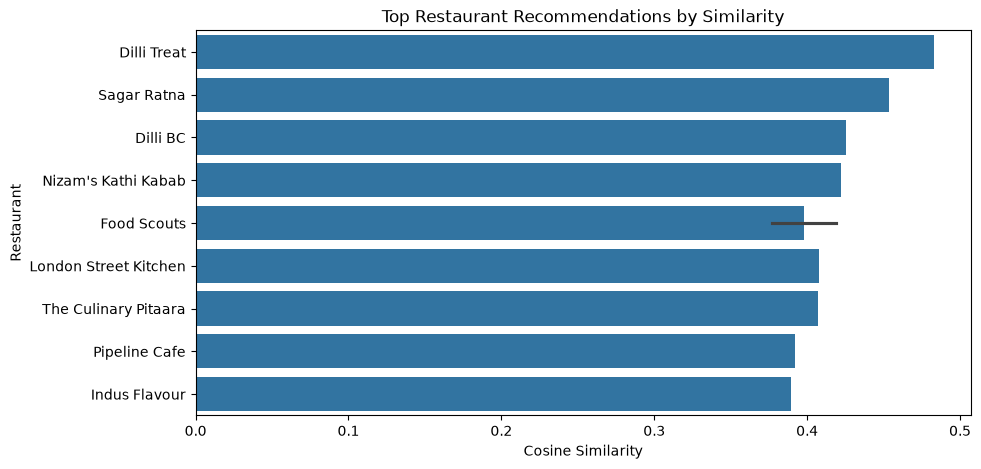

In [56]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=recommendations,
    x="Similarity Score",
    y="Restaurant Name"
)

plt.title(
    "Top Restaurant Recommendations by Similarity"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Restaurant")

plt.savefig(
    "../outputs/figures/task2_recommendation_similarity.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [57]:
recommendation_summary = recommendations[
    [
        "Restaurant Name",
        "City",
        "Locality",
        "Cuisines",
        "Price range",
        "Aggregate rating",
        "Similarity Score"
    ]
].copy()

recommendation_summary

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,0.453838
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,0.389284
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,0.377300


In [58]:
recommendation_summary.to_csv(
    "../outputs/results/task2_recommendation_summary.csv",
    index=False
)

In [59]:
recommend_restaurants(
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery="Yes",
    top_n=10
)

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,yes,No,"north indian, south indian, chinese rajinder n...",0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,yes,No,"south indian, north indian, chinese defence co...",0.453838
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,yes,No,"north indian, mughlai malviya nagar new delhi",0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,yes,Yes,"north indian, fast food malviya nagar new delhi",0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,yes,No,"north indian, chinese, continental janakpuri n...",0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,yes,Yes,"north indian, mughlai, chinese rajinder nagar ...",0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,yes,No,"north indian, chinese defence colony new delhi",0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,yes,No,"cafe, north indian, chinese, continental satya...",0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,yes,Yes,"north indian, chinese, cafe delhi university-g...",0.389284
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,yes,No,"north indian, chinese, continental rajouri gar...",0.377300


The recommendation system uses content-based similarity based
primarily on cuisine and location-related textual features.
Price range, minimum rating, and online delivery are applied as
user preference filters before similarity-based ranking.

# Task 2 — Conclusion

A content-based restaurant recommendation system was developed
using the restaurant dataset.

The system accepts user preferences including:

- City
- Cuisine
- Price range
- Minimum rating
- Online delivery preference

Restaurants are first filtered according to the selected hard
constraints. The remaining restaurant profiles are represented
using TF-IDF based on cuisine and location-related text features.
Cosine similarity is then used to rank restaurants according to
their similarity to the user's preferences.

The system was tested using multiple sample user preference
combinations and successfully returned ranked restaurant
recommendations.

### Limitation

The dataset does not contain actual user-item interaction or
feedback data. Therefore, conventional recommendation metrics
such as precision@k or recall@k cannot be reliably calculated
from the provided dataset alone. Recommendation quality was
instead validated using preference-matching checks and
similarity scores.

In [60]:
test_recommendations = recommend_restaurants(
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery="Yes",
    top_n=10
)

test_recommendations

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,yes,No,"north indian, south indian, chinese rajinder n...",0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,yes,No,"south indian, north indian, chinese defence co...",0.453838
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,yes,No,"north indian, mughlai malviya nagar new delhi",0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,yes,Yes,"north indian, fast food malviya nagar new delhi",0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,yes,No,"north indian, chinese, continental janakpuri n...",0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,yes,Yes,"north indian, mughlai, chinese rajinder nagar ...",0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,yes,No,"north indian, chinese defence colony new delhi",0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,yes,No,"cafe, north indian, chinese, continental satya...",0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,yes,Yes,"north indian, chinese, cafe delhi university-g...",0.389284
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,yes,No,"north indian, chinese, continental rajouri gar...",0.377300


In [61]:
print("Number of recommendations:", len(test_recommendations))

Number of recommendations: 10


In [62]:
def display_recommendations(recommendations):
    if recommendations.empty:
        print("No restaurants match the selected preferences.")
        return

    display(
        recommendations[
            [
                "Restaurant Name",
                "City",
                "Locality",
                "Cuisines",
                "Price range",
                "Aggregate rating",
                "Has Online delivery",
                "Similarity Score"
            ]
        ]
    )

In [63]:
display_recommendations(test_recommendations)

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,yes,0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,yes,0.453838
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,yes,0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,yes,0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,yes,0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,yes,0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,yes,0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,yes,0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,yes,0.389284
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,yes,0.377300


In [64]:
user_1 = {
    "city": "New Delhi",
    "cuisine": "North Indian",
    "price_range": 2,
    "min_rating": 4.0,
    "online_delivery": "Yes",
    "top_n": 10
}

result_1 = recommend_restaurants(**user_1)

display_recommendations(result_1)

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,yes,0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,yes,0.453838
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,yes,0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,yes,0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,yes,0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,yes,0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,yes,0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,yes,0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,yes,0.389284
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,yes,0.377300


In [65]:
print("Recommendations returned:", len(result_1))

Recommendations returned: 10


In [66]:
user_2 = {
    "city": "Gurgaon",
    "cuisine": "Chinese",
    "price_range": 2,
    "min_rating": 3.5,
    "online_delivery": "Yes",
    "top_n": 10
}

result_2 = recommend_restaurants(**user_2)

display_recommendations(result_2)

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Similarity Score
2030,Cafe Cup of Life,gurgaon,sector 7,"cafe, fast food, chinese",2,3.7,yes,0.562182
1388,Happy Beings,gurgaon,dlf phase 3,"north indian, mughlai, chinese",2,3.5,yes,0.472055
1324,Angrezee Choupal,gurgaon,dlf phase 2,"north indian, chinese, italian",2,3.8,yes,0.465902
1384,China Gatherings,gurgaon,dlf phase 3,"chinese, thai",2,3.5,yes,0.456334
1413,My Country Platter,gurgaon,dlf phase 4,"asian, chinese, north indian",2,3.8,yes,0.436167
1943,Nite Bites,gurgaon,sector 45,"north indian, chinese, continental",2,3.7,yes,0.422729
2082,Tandoori Nation,gurgaon,sohna road,"north indian, mughlai, chinese",2,3.5,yes,0.418392
1421,Happy Hakka,gurgaon,dlf phase 4,"chinese, asian, thai",2,4.1,yes,0.398965
2128,Dilli Darbar,gurgaon,sushant lok,"north indian, mughlai, chinese",2,3.7,yes,0.388369
1491,The Gathering Hut,gurgaon,golf course road,"north indian, chinese",2,3.5,yes,0.380008


In [67]:
user_3 = {
    "city": "New Delhi",
    "cuisine": "Italian",
    "price_range": 3,
    "min_rating": 4.0,
    "online_delivery": None,
    "top_n": 5
}

result_3 = recommend_restaurants(**user_3)

display_recommendations(result_3)

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Similarity Score
7359,Circus,new delhi,south extension 2,"north indian, chinese, italian",3,4.0,yes,0.487844
6717,The Drunk House,new delhi,rajouri garden,"north indian, italian, chinese",3,4.2,no,0.460238
3120,{Niche} - Cafe & Bar,new delhi,connaught place,"north indian, chinese, italian, continental",3,4.1,no,0.438872
3093,Ambrosia Bliss,new delhi,connaught place,"north indian, chinese, italian, continental",3,4.0,no,0.438872
3976,Summer House Cafe,new delhi,hauz khas,"italian, continental",3,4.1,no,0.434351


In [68]:
user_4 = {
    "city": "New Delhi",
    "cuisine": "Japanese",
    "price_range": 4,
    "min_rating": 4.9,
    "online_delivery": "Yes",
    "top_n": 10
}

result_4 = recommend_restaurants(**user_4)

display_recommendations(result_4)

No restaurants match the selected preferences.
No restaurants match the selected preferences.


In [69]:
user_5 = {
    "city": "New Delhi",
    "cuisine": "North Indian",
    "price_range": 2,
    "min_rating": 0.0,
    "online_delivery": None,
    "top_n": 10
}

result_5 = recommend_restaurants(**user_5)

display_recommendations(result_5)

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Similarity Score
6113,Recipe Tadka,new delhi,palam,north indian,2,0.0,no,0.536250
7908,Shan E Punjab,new delhi,vikaspuri,"north indian, south indian",2,3.4,no,0.519151
6315,Sagar Ratna,new delhi,pitampura,"south indian, north indian, chinese",2,2.3,yes,0.517749
6298,Peshawari,new delhi,pitampura,north indian,2,3.6,no,0.516574
6281,The Taste of Delhi,new delhi,pitampura,north indian,2,3.3,yes,0.516574
6239,Chacha Shankar,new delhi,pitampura,north indian,2,3.2,no,0.516574
6268,Puran Chand,new delhi,pitampura,north indian,2,2.6,yes,0.516574
5765,Choice,new delhi,naraina,"south indian, north indian",2,3.0,no,0.514577
7106,Gulshan,new delhi,shahdara,north indian,2,3.3,no,0.514336
7115,Paramjeet Fish & Chicken Point,new delhi,shahdara,north indian,2,3.1,no,0.514336


In [70]:
test_summary = pd.DataFrame({
    "Test Case": [
        "North Indian - New Delhi",
        "Chinese - Gurgaon",
        "Italian - New Delhi",
        "Restrictive Japanese",
        "North Indian - Relaxed"
    ],
    "Requested Cuisine": [
        "North Indian",
        "Chinese",
        "Italian",
        "Japanese",
        "North Indian"
    ],
    "Requested City": [
        "New Delhi",
        "Gurgaon",
        "New Delhi",
        "New Delhi",
        "New Delhi"
    ],
    "Recommendations Returned": [
        len(result_1),
        len(result_2),
        len(result_3),
        len(result_4),
        len(result_5)
    ]
})

test_summary

,Test Case,Requested Cuisine,Requested City,Recommendations Returned
0,North Indian - New Delhi,North Indian,New Delhi,10
1,Chinese - Gurgaon,Chinese,Gurgaon,10
2,Italian - New Delhi,Italian,New Delhi,5
3,Restrictive Japanese,Japanese,New Delhi,0
4,North Indian - Relaxed,North Indian,New Delhi,10


In [71]:
def validate_recommendations(
    recommendations,
    city,
    cuisine,
    price_range,
    min_rating,
    online_delivery=None
):
    if recommendations.empty:
        return {
            "recommendations": 0,
            "city_match": 0,
            "cuisine_match": 0,
            "price_match": 0,
            "rating_match": 0,
            "delivery_match": 0 if online_delivery else None
        }

    city_match = (
        recommendations["City"]
        .str.lower()
        .eq(city.lower())
        .all()
    )

    cuisine_match = (
        recommendations["Cuisines"]
        .str.contains(
            cuisine,
            case=False,
            na=False,
            regex=False
        )
        .all()
    )

    price_match = (
        recommendations["Price range"] == price_range
    ).all()

    rating_match = (
        recommendations["Aggregate rating"] >= min_rating
    ).all()

    if online_delivery is not None:
        delivery_match = (
            recommendations["Has Online delivery"]
            .str.lower()
            .eq(online_delivery.lower())
            .all()
        )
    else:
        delivery_match = None

    return {
        "recommendations": len(recommendations),
        "city_match": city_match,
        "cuisine_match": cuisine_match,
        "price_match": price_match,
        "rating_match": rating_match,
        "delivery_match": delivery_match
    }

In [72]:
validation_1 = validate_recommendations(
    result_1,
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery="Yes"
)

validation_1

{'recommendations': 10,
 'city_match': np.True_,
 'cuisine_match': np.True_,
 'price_match': np.True_,
 'rating_match': np.True_,
 'delivery_match': np.True_}

In [73]:
validation_2 = validate_recommendations(
    result_2,
    city="Gurgaon",
    cuisine="Chinese",
    price_range=2,
    min_rating=3.5,
    online_delivery="Yes"
)

validation_2

{'recommendations': 10,
 'city_match': np.True_,
 'cuisine_match': np.True_,
 'price_match': np.True_,
 'rating_match': np.True_,
 'delivery_match': np.True_}

In [74]:
evaluation_results = pd.DataFrame([
    validation_1,
    validation_2,
    validate_recommendations(
        result_3,
        city="New Delhi",
        cuisine="Italian",
        price_range=3,
        min_rating=4.0,
        online_delivery=None
    )
])

evaluation_results

,recommendations,city_match,cuisine_match,price_match,rating_match,delivery_match
0,10,True,True,True,True,True
1,10,True,True,True,True,True
2,5,True,True,True,True,None


In [75]:
print(
    "Average similarity:",
    round(
        result_1["Similarity Score"].mean(),
        4
    )
)

Average similarity: 0.4176


In [76]:
print(
    "Highest similarity:",
    round(
        result_1["Similarity Score"].max(),
        4
    )
)

print(
    "Lowest similarity:",
    round(
        result_1["Similarity Score"].min(),
        4
    )
)

Highest similarity: 0.4828
Lowest similarity: 0.3773


In [77]:
result_1[
    [
        "Restaurant Name",
        "Cuisines",
        "Aggregate rating",
        "Similarity Score"
    ]
].sort_values(
    "Similarity Score",
    ascending=False
)

,Restaurant Name,Cuisines,Aggregate rating,Similarity Score
6617,Dilli Treat,"north indian, south indian, chinese",4.2,0.482778
3267,Sagar Ratna,"south indian, north indian, chinese",4.0,0.453838
5199,Dilli BC,"north indian, mughlai",4.4,0.425542
5201,Nizam's Kathi Kabab,"north indian, fast food",4.0,0.422019
4225,Food Scouts,"north indian, chinese, continental",4.3,0.418579
6620,London Street Kitchen,"north indian, mughlai, chinese",4.2,0.407703
3268,The Culinary Pitaara,"north indian, chinese",4.2,0.407309
7040,Pipeline Cafe,"cafe, north indian, chinese, continental",4.0,0.391868
3334,Indus Flavour,"north indian, chinese, cafe",4.1,0.389284
6705,Food Scouts,"north indian, chinese, continental",4.4,0.377300


In [78]:
recommendations = recommend_restaurants(
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery="Yes",
    top_n=10
)

recommendations

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,yes,No,"north indian, south indian, chinese rajinder n...",0.482778
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,yes,No,"south indian, north indian, chinese defence co...",0.453838
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,yes,No,"north indian, mughlai malviya nagar new delhi",0.425542
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,yes,Yes,"north indian, fast food malviya nagar new delhi",0.422019
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,yes,No,"north indian, chinese, continental janakpuri n...",0.418579
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,yes,Yes,"north indian, mughlai, chinese rajinder nagar ...",0.407703
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,yes,No,"north indian, chinese defence colony new delhi",0.407309
7040,Pipeline Cafe,new delhi,satyaniketan,"cafe, north indian, chinese, continental",2,4.0,yes,No,"cafe, north indian, chinese, continental satya...",0.391868
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,yes,Yes,"north indian, chinese, cafe delhi university-g...",0.389284
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,yes,No,"north indian, chinese, continental rajouri gar...",0.377300


In [79]:
print(recommendations.columns.tolist())

['Restaurant Name', 'City', 'Locality', 'Cuisines', 'Price range', 'Aggregate rating', 'Has Online delivery', 'Has Table booking', 'content', 'Similarity Score']


In [80]:
filtered_df["City"] == "new delhi"

3096    True
3103    True
3110    True
3262    True
3263    True
3267    True
3268    True
3269    True
3310    True
3334    True
3337    True
3694    True
3697    True
3698    True
3701    True
3704    True
3705    True
3707    True
3771    True
3774    True
3998    True
4206    True
4225    True
4320    True
4525    True
4956    True
5199    True
5201    True
5202    True
5203    True
5204    True
5501    True
6135    True
6426    True
6617    True
6619    True
6620    True
6705    True
6710    True
6847    True
6850    True
7040    True
7041    True
7042    True
7043    True
7044    True
7045    True
7086    True
7193    True
7194    True
7195    True
7198    True
7199    True
7360    True
7616    True
7727    True
7728    True
7729    True
7865    True
Name: City, dtype: bool

In [86]:
def recommend_restaurants(
    city,
    cuisine,
    price_range,
    min_rating=0.0,
    online_delivery=None,
    top_n=10
):
    """
    Recommend restaurants based on user preferences.
    """

    # -----------------------------
    # 1. Input validation
    # -----------------------------
    if not city:
        raise ValueError("City cannot be empty.")

    if not cuisine:
        raise ValueError("Cuisine cannot be empty.")

    if price_range not in [1, 2, 3, 4]:
        raise ValueError(
            "Price range must be between 1 and 4."
        )

    if not (0 <= min_rating <= 5):
        raise ValueError(
            "Minimum rating must be between 0 and 5."
        )

    # -----------------------------
    # 2. Work on a copy
    # -----------------------------
    filtered_df = rec_df.copy()

    # -----------------------------
    # 3. Normalize user inputs
    # -----------------------------
    city = str(city).strip().lower()
    cuisine = str(cuisine).strip().lower()

    # -----------------------------
    # 4. Normalize text columns
    # -----------------------------
    filtered_df["City"] = (
        filtered_df["City"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    filtered_df["Cuisines"] = (
        filtered_df["Cuisines"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    filtered_df["Has Online delivery"] = (
        filtered_df["Has Online delivery"]
        .fillna("No")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # -----------------------------
    # 5. Filter by city
    # -----------------------------
    filtered_df = filtered_df[
        filtered_df["City"] == city
    ]

    # -----------------------------
    # 6. Filter by cuisine
    # -----------------------------
    filtered_df = filtered_df[
        filtered_df["Cuisines"].str.contains(
            cuisine,
            case=False,
            na=False,
            regex=False
        )
    ]

    # -----------------------------
    # 7. Filter by price range
    # -----------------------------
    filtered_df = filtered_df[
        filtered_df["Price range"] == price_range
    ]

    # -----------------------------
    # 8. Filter by minimum rating
    # -----------------------------
    filtered_df = filtered_df[
        filtered_df["Aggregate rating"] >= min_rating
    ]

    # -----------------------------
    # 9. Filter by online delivery
    # -----------------------------
    if online_delivery is not None:

        online_delivery = (
            str(online_delivery)
            .strip()
            .lower()
        )

        filtered_df = filtered_df[
            filtered_df["Has Online delivery"]
            == online_delivery
        ]

    # -----------------------------
    # 10. Check for no results
    # -----------------------------
    if filtered_df.empty:
        print(
            "No restaurants match the selected preferences."
        )

        return pd.DataFrame(columns=[
            "Restaurant Name",
            "City",
            "Locality",
            "Cuisines",
            "Price range",
            "Aggregate rating",
            "Has Online delivery",
            "Similarity Score",
            "Rating Score",
            "Final Score"
        ])

    # -----------------------------
    # 11. Create user preference text
    # -----------------------------
    user_content = cuisine + " " + city

    # -----------------------------
    # 12. Convert user preference to TF-IDF
    # -----------------------------
    user_vector = tfidf.transform(
        [user_content]
    )

    # -----------------------------
    # 13. Calculate similarity
    # -----------------------------
    similarities = cosine_similarity(
        user_vector,
        tfidf_matrix[filtered_df.index]
    ).flatten()

    # -----------------------------
    # 14. Add similarity score
    # -----------------------------
    filtered_df["Similarity Score"] = similarities

    # -----------------------------
    # 15. Create rating score
    # -----------------------------
    filtered_df["Rating Score"] = (
        filtered_df["Aggregate rating"] / 5
    )

    # -----------------------------
    # 16. Create final ranking score
    # -----------------------------
    filtered_df["Final Score"] = (
        0.7 * filtered_df["Similarity Score"]
        + 0.3 * filtered_df["Rating Score"]
    )

    # -----------------------------
    # 17. Rank restaurants
    # -----------------------------
    filtered_df = filtered_df.sort_values(
        by="Final Score",
        ascending=False
    )

    # -----------------------------
    # 18. Return Top N
    # -----------------------------
    return filtered_df.head(top_n)

In [91]:
recommendations = recommend_restaurants(
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery="Yes",
    top_n=10
)

recommendations

,Restaurant Name,City,Locality,Cuisines,Price range,Aggregate rating,Has Online delivery,Has Table booking,content,Similarity Score,Rating Score,Final Score
6617,Dilli Treat,new delhi,rajinder nagar,"north indian, south indian, chinese",2,4.2,yes,No,"north indian, south indian, chinese rajinder n...",0.482778,0.84,0.589945
5199,Dilli BC,new delhi,malviya nagar,"north indian, mughlai",2,4.4,yes,No,"north indian, mughlai malviya nagar new delhi",0.425542,0.88,0.561880
3267,Sagar Ratna,new delhi,defence colony,"south indian, north indian, chinese",2,4.0,yes,No,"south indian, north indian, chinese defence co...",0.453838,0.80,0.557687
4225,Food Scouts,new delhi,janakpuri,"north indian, chinese, continental",2,4.3,yes,No,"north indian, chinese, continental janakpuri n...",0.418579,0.86,0.551005
6620,London Street Kitchen,new delhi,rajinder nagar,"north indian, mughlai, chinese",2,4.2,yes,Yes,"north indian, mughlai, chinese rajinder nagar ...",0.407703,0.84,0.537392
3268,The Culinary Pitaara,new delhi,defence colony,"north indian, chinese",2,4.2,yes,No,"north indian, chinese defence colony new delhi",0.407309,0.84,0.537116
5201,Nizam's Kathi Kabab,new delhi,malviya nagar,"north indian, fast food",2,4.0,yes,Yes,"north indian, fast food malviya nagar new delhi",0.422019,0.80,0.535413
6426,Food Scouts,new delhi,punjabi bagh,"north indian, chinese, continental",2,4.6,yes,No,"north indian, chinese, continental punjabi bag...",0.362045,0.92,0.529431
6705,Food Scouts,new delhi,rajouri garden,"north indian, chinese, continental",2,4.4,yes,No,"north indian, chinese, continental rajouri gar...",0.377300,0.88,0.528110
3334,Indus Flavour,new delhi,delhi university-gtb nagar,"north indian, chinese, cafe",2,4.1,yes,Yes,"north indian, chinese, cafe delhi university-g...",0.389284,0.82,0.518499


In [92]:
recommendations[
    [
        "Restaurant Name",
        "City",
        "Cuisines",
        "Price range",
        "Aggregate rating",
        "Similarity Score",
        "Rating Score",
        "Final Score"
    ]
]

,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Similarity Score,Rating Score,Final Score
6617,Dilli Treat,new delhi,"north indian, south indian, chinese",2,4.2,0.482778,0.84,0.589945
5199,Dilli BC,new delhi,"north indian, mughlai",2,4.4,0.425542,0.88,0.561880
3267,Sagar Ratna,new delhi,"south indian, north indian, chinese",2,4.0,0.453838,0.80,0.557687
4225,Food Scouts,new delhi,"north indian, chinese, continental",2,4.3,0.418579,0.86,0.551005
6620,London Street Kitchen,new delhi,"north indian, mughlai, chinese",2,4.2,0.407703,0.84,0.537392
3268,The Culinary Pitaara,new delhi,"north indian, chinese",2,4.2,0.407309,0.84,0.537116
5201,Nizam's Kathi Kabab,new delhi,"north indian, fast food",2,4.0,0.422019,0.80,0.535413
6426,Food Scouts,new delhi,"north indian, chinese, continental",2,4.6,0.362045,0.92,0.529431
6705,Food Scouts,new delhi,"north indian, chinese, continental",2,4.4,0.377300,0.88,0.528110
3334,Indus Flavour,new delhi,"north indian, chinese, cafe",2,4.1,0.389284,0.82,0.518499


In [87]:
result_1[
    [
        "Restaurant Name",
        "Cuisines",
        "Aggregate rating",
        "Similarity Score"
    ]
].sort_values(
    "Similarity Score",
    ascending=False
)

,Restaurant Name,Cuisines,Aggregate rating,Similarity Score
6617,Dilli Treat,"north indian, south indian, chinese",4.2,0.482778
3267,Sagar Ratna,"south indian, north indian, chinese",4.0,0.453838
5199,Dilli BC,"north indian, mughlai",4.4,0.425542
5201,Nizam's Kathi Kabab,"north indian, fast food",4.0,0.422019
4225,Food Scouts,"north indian, chinese, continental",4.3,0.418579
6620,London Street Kitchen,"north indian, mughlai, chinese",4.2,0.407703
3268,The Culinary Pitaara,"north indian, chinese",4.2,0.407309
7040,Pipeline Cafe,"cafe, north indian, chinese, continental",4.0,0.391868
3334,Indus Flavour,"north indian, chinese, cafe",4.1,0.389284
6705,Food Scouts,"north indian, chinese, continental",4.4,0.377300


In [88]:
filtered_df["Rating Score"] = (
    filtered_df["Aggregate rating"] / 5
)

In [98]:
result_1["Cuisines"].nunique()

9

In [99]:
result_1["Locality"].nunique()

7

In [100]:
print(
    "Unique cuisine combinations:",
    result_1["Cuisines"].nunique()
)

print(
    "Unique localities:",
    result_1["Locality"].nunique()
)

Unique cuisine combinations: 9
Unique localities: 7


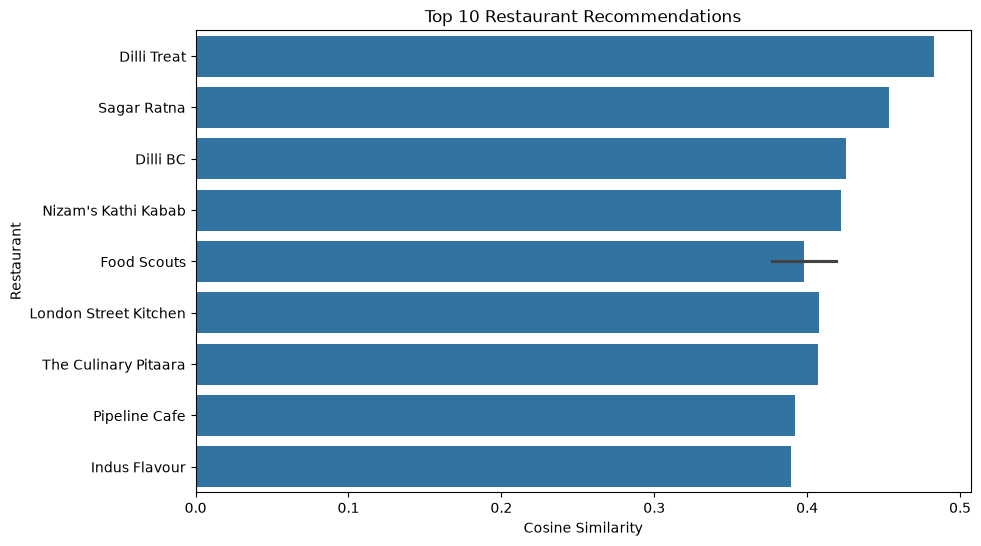

In [101]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=result_1,
    x="Similarity Score",
    y="Restaurant Name"
)

plt.title(
    "Top 10 Restaurant Recommendations"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Restaurant")

plt.savefig(
    "../outputs/figures/task2_final_recommendations.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [96]:
test_summary.to_csv(
    "../outputs/results/task2_test_summary.csv",
    index=False
)

In [95]:
evaluation_results.to_csv(
    "../outputs/results/task2_evaluation_results.csv",
    index=False
)

In [97]:
result_1.to_csv(
    "../outputs/results/task2_final_sample_recommendations.csv",
    index=False
)

# Task 2 — Methodology

The restaurant recommendation system uses a content-based
filtering approach.

### Step 1 — User Preferences

The system accepts:

- City
- Cuisine
- Price range
- Minimum rating
- Online delivery preference

### Step 2 — Filtering

Restaurants are filtered according to the user's city,
cuisine, price range, minimum rating, and optional online
delivery preference.

### Step 3 — Content Representation

Restaurant content is represented using cuisine, locality,
and city information.

### Step 4 — TF-IDF

TF-IDF is used to convert the textual restaurant profiles
into numerical feature vectors.

### Step 5 — Similarity

Cosine similarity measures the similarity between the user's
cuisine/location preferences and the restaurant profiles.

### Step 6 — Ranking

Restaurants are ranked using their similarity scores, with
restaurant rating used as a secondary ranking criterion.

### Step 7 — Recommendations

The top N restaurants are returned to the user.

# Task 2 — Evaluation

The recommendation system was tested using multiple user
preference combinations involving different cities, cuisines,
price ranges, minimum ratings, and delivery requirements.

The returned recommendations were checked against the requested
constraints to verify that they satisfied the selected
preferences.

The system was also tested with highly restrictive preferences
to verify that it handles cases where no matching restaurants
are available.

Cosine similarity scores were analyzed to understand the
content-based ranking of the returned restaurants.

## Limitations

The provided restaurant dataset does not contain explicit
user-item interaction data, such as historical user ratings,
clicks, bookings, or purchases.

Therefore, conventional recommender-system evaluation metrics
such as precision@K, recall@K, or NDCG cannot be reliably
calculated from this dataset alone.

Instead, the system is evaluated using preference-matching
validation, similarity scores, and multiple sample user
scenarios.

# Task 2 — Conclusion

A content-based restaurant recommendation system was successfully
implemented using the Cognifyz restaurant dataset.

The system accepts user preferences such as city, cuisine,
price range, minimum rating, and online delivery. Suitable
restaurants are first identified using preference-based filters,
after which TF-IDF and cosine similarity are used to rank the
restaurants according to their content similarity.

Multiple sample user scenarios were tested, including normal
and highly restrictive preferences. The recommendations were
validated against the selected constraints, and similarity
scores were analyzed to evaluate the ranking.

The system provides an explainable recommendation approach
using the available restaurant attributes. However, the absence
of historical user-interaction data limits the use of standard
personalized recommendation evaluation metrics.

                 USER
                  │
                  ▼
          User Preferences
                  │
       ┌──────────┼──────────┐
       ▼          ▼          ▼
     City      Cuisine    Price
       │          │          │
       └──────────┼──────────┘
                  ▼
            Hard Filtering
                  │
                  ▼
        Matching Restaurants
                  │
                  ▼
          TF-IDF Representation
                  │
                  ▼
          Cosine Similarity
                  │
                  ▼
             Ranking
                  │
                  ▼
            Top N Results

In [103]:
def recommend_restaurants(
    city,
    cuisine,
    price_range,
    min_rating=0.0,
    online_delivery=None,
    top_n=10
):
    ...

In [106]:
def recommend_restaurants(
    city,
    cuisine,
    price_range,
    min_rating=0.0,
    online_delivery=None,
    top_n=10
):

    # Input validation
    if not city:
        raise ValueError("City cannot be empty.")

    if not cuisine:
        raise ValueError("Cuisine cannot be empty.")

    if price_range not in [1, 2, 3, 4]:
        raise ValueError(
            "Price range must be between 1 and 4."
        )

    if not (0 <= min_rating <= 5):
        raise ValueError(
            "Minimum rating must be between 0 and 5."
        )

    # Rest of your recommendation code...

In [107]:
recommendations = recommend_restaurants(
    city="New Delhi",
    cuisine="North Indian",
    price_range=2,
    min_rating=4.0,
    online_delivery="Yes",
    top_n=10
)

recommendations

### Ranking Strategy

The recommendation ranking combines content similarity and
restaurant rating. A weighted score is calculated as:

Final Score = 0.7 × Similarity Score + 0.3 × Rating Score

The higher weight is assigned to content similarity so that
recommendations remain primarily aligned with the user's
preferences, while restaurant rating contributes as a secondary
quality factor.